In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Load Data
# ---------------------------
# Using the path from your dictionary
path = "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/BeastfMRIN30.xlsx"
df_fmri = pd.read_excel(path)


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [18]:
import pandas as pd
import numpy as np
from math import gcd
from collections import Counter

# 1. Get all distances between changes for EVERY subject
all_lengths = []

for subj in df_fmri['SubjID'].unique():
    subj_data = df_fmri[df_fmri['SubjID'] == subj].reset_index(drop=True)
    
    # Find indices of change
    change_indices = subj_data.index[subj_data['Load'].diff().fillna(0) != 0].tolist()
    boundaries = [0] + change_indices + [len(subj_data)]
    
    # Calculate lengths
    lengths = [boundaries[i] - boundaries[i-1] for i in range(1, len(boundaries))]
    all_lengths.extend(lengths)

# 2. See which lengths are most common
counts = Counter(all_lengths)
print("--- Frequency of interval lengths ---")
for length, freq in counts.most_common(5):
    print(f"Interval of {length} trials occurred {freq} times")

# 3. The "Atomic Unit" Check
# If 48 is the block size, we expect to see 48, 96, 144 etc.
print(f"\nSmallest interval found: {min(all_lengths)}")

--- Frequency of interval lengths ---
Interval of 47 trials occurred 54 times
Interval of 48 trials occurred 44 times
Interval of 94 trials occurred 19 times
Interval of 46 trials occurred 12 times
Interval of 49 trials occurred 6 times

Smallest interval found: 46


In [19]:
all_transitions = []

for subj in df_fmri['SubjID'].unique():
    subj_df = df_fmri[df_fmri['SubjID'] == subj].reset_index()
    
    change_indices = subj_df.index[subj_df['Load'].diff().fillna(0) != 0].tolist()
    
    for idx in change_indices:
        if idx < 45: continue
        
        # Look back at the 48 trials
        prior_block = subj_df.loc[idx-48 : idx-1].copy()
        
        # --- THE FILTER ---
        # Only count Go Trials (Stop1OrNoStop2 == 2) 
        # AND Only count Targets/Non-Targets (ignore Code 3 Lures)
        clean_trials = prior_block[
            (prior_block['Stop1OrNoStop2'] == 2) & 
            (prior_block['Target1NonTarget2TempNonTarget3'] != 3)
        ]
        
        if len(clean_trials) == 0: continue
            
        clean_acc = clean_trials['GoAcc'].mean()
        
        direction = "Increase" if subj_df.loc[idx, 'Load'] > subj_df.loc[idx-1, 'Load'] else "Decrease"
        
        all_transitions.append({'Accuracy': clean_acc, 'Direction': direction})

transition_df = pd.DataFrame(all_transitions)
print(transition_df.groupby('Direction')['Accuracy'].agg(['mean', 'min', 'max']))

               mean       min       max
Direction                              
Decrease   0.718488  0.500000  0.806452
Increase   0.961256  0.903226  1.000000


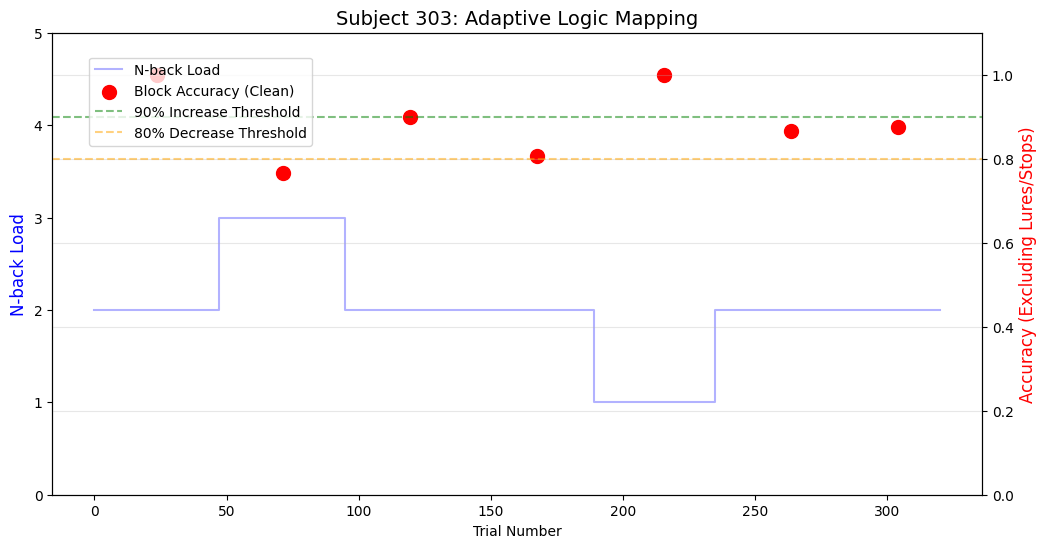

In [20]:
import matplotlib.pyplot as plt

# 1. Setup the data for Subject 303
subj_id = 303
subj_data = df_fmri[df_fmri['SubjID'] == subj_id].copy().reset_index()
subj_data['BlockID'] = subj_data.index // 48

# 2. Calculate "Clean Accuracy" per block (No Lures, No Stops)
def get_clean_acc(group):
    # Filter for Go trials that are NOT Lures
    clean = group[(group['Stop1OrNoStop2'] == 2) & (group['Target1NonTarget2TempNonTarget3'] != 3)]
    return clean['GoAcc'].mean()

# We convert x.index to a Series so we can call .mean() on it
block_stats = subj_data.groupby('BlockID').apply(lambda x: pd.Series({
    'CleanAcc': get_clean_acc(x),
    'Load': x['Load'].iloc[0],
    'Midpoint': x.index.to_series().mean()  # <-- FIXED: Added .to_series()
}), include_groups=False).reset_index()

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Load (The Staircase)
ax1.step(subj_data.index, subj_data['Load'], where='post', color='blue', alpha=0.3, label='N-back Load')
ax1.set_ylabel('N-back Load', color='blue', fontsize=12)
ax1.set_ylim(0, 5)

# Plot the Clean Accuracy dots
ax2 = ax1.twinx()
ax2.scatter(block_stats['Midpoint'], block_stats['CleanAcc'], color='red', s=100, label='Block Accuracy (Clean)')
ax2.axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='90% Increase Threshold')
ax2.axhline(y=0.80, color='orange', linestyle='--', alpha=0.5, label='80% Decrease Threshold')
ax2.set_ylabel('Accuracy (Excluding Lures/Stops)', color='red', fontsize=12)
ax2.set_ylim(0, 1.1)

plt.title(f"Subject {subj_id}: Adaptive Logic Mapping", fontsize=14)
ax1.set_xlabel('Trial Number')
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))
plt.grid(axis='y', alpha=0.3)
plt.show()